In [64]:
# Sales Data Analysis using Python and SQL

#This project analyzes sales data to identify revenue patterns, customer preferences, and business insights using Python, SQL, and data visualization.

In [62]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [41]:
## Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [42]:
## Load Dataset
df = pd.read_csv("eda_sales_dataset.csv")
df.head(200)

,Order_ID,Order_Date,Customer_Name,City,Product,Category,Quantity,Unit_Price,Payment_Method,Discount,Rating
0,1001,2024-06-12,Priya,Chennai,Keyboard,Electronics,3,1200,Card,2000,5
1,1002,2024-01-29,Sneha,Mumbai,Phone,Electronics,4,30000,UPI,500,4
2,1003,2024-01-07,Ravi,Delhi,Monitor,Electronics,2,15000,Card,0,4
3,1004,2024-03-11,Ravi,Chennai,Monitor,Electronics,1,15000,UPI,0,5
4,1005,2024-03-03,Neha,Bangalore,Laptop,Electronics,3,55000,Net Banking,0,5
...,...,...,...,...,...,...,...,...,...,...,...
195,1196,2024-05-16,Sneha,Pune,Headphones,Electronics,1,2000,Net Banking,500,3
196,1197,2024-02-02,Arjun,Hyderabad,Phone,Electronics,3,30000,Card,2000,3
197,1198,2024-02-02,Vikram,Pune,Headphones,Electronics,3,2000,UPI,1000,3
198,1199,2024-06-17,Arjun,Chennai,Phone,Electronics,5,30000,UPI,1000,5


In [43]:
conn = sqlite3.connect("sales.db")

In [44]:
df.to_sql("sales", conn, if_exists="replace", index=False)

200

In [45]:
query = "SELECT * FROM sales LIMIT 5"
pd.read_sql(query, conn)

,Order_ID,Order_Date,Customer_Name,City,Product,Category,Quantity,Unit_Price,Payment_Method,Discount,Rating
0,1001,2024-06-12,Priya,Chennai,Keyboard,Electronics,3,1200,Card,2000,5
1,1002,2024-01-29,Sneha,Mumbai,Phone,Electronics,4,30000,UPI,500,4
2,1003,2024-01-07,Ravi,Delhi,Monitor,Electronics,2,15000,Card,0,4
3,1004,2024-03-11,Ravi,Chennai,Monitor,Electronics,1,15000,UPI,0,5
4,1005,2024-03-03,Neha,Bangalore,Laptop,Electronics,3,55000,Net Banking,0,5


In [46]:
query = """
SELECT SUM(Quantity * Unit_Price - Discount) AS Total_Revenue
FROM sales
"""
pd.read_sql(query, conn)

,Total_Revenue
0,10801600


In [47]:
query = """
SELECT Product,
SUM(Quantity * Unit_Price - Discount) AS Revenue
FROM sales
GROUP BY Product
ORDER BY Revenue DESC
"""
pd.read_sql(query, conn)

,Product,Revenue
0,Laptop,3892000
1,Tablet,2556000
2,Phone,2437500
3,Monitor,1053000
4,Printer,710500
5,Headphones,76500
6,Keyboard,55100
7,Mouse,21000


In [48]:
query = """
SELECT City,
SUM(Quantity * Unit_Price - Discount) AS Revenue
FROM sales
GROUP BY City
ORDER BY Revenue DESC
"""
pd.read_sql(query, conn)

,City,Revenue
0,Delhi,2207500
1,Hyderabad,1840100
2,Mumbai,1823700
3,Chennai,1669100
4,Pune,1647500
5,Bangalore,1613700


In [49]:
query = """
SELECT Payment_Method,
COUNT(*) AS Total_Orders
FROM sales
GROUP BY Payment_Method
ORDER BY Total_Orders DESC
"""
pd.read_sql(query, conn)

,Payment_Method,Total_Orders
0,UPI,54
1,Cash,54
2,Card,48
3,Net Banking,44


In [50]:
query = """
SELECT AVG(Rating) AS Average_Rating
FROM sales
"""
pd.read_sql(query, conn)

,Average_Rating
0,3.935


In [53]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Customer_Name', 'City', 'Product',
       'Category', 'Quantity', 'Unit_Price', 'Payment_Method', 'Discount',
       'Rating'],
      dtype='object')


In [55]:
df["Revenue"] = df["Quantity"] * df["Unit_Price"] - df["Discount"]

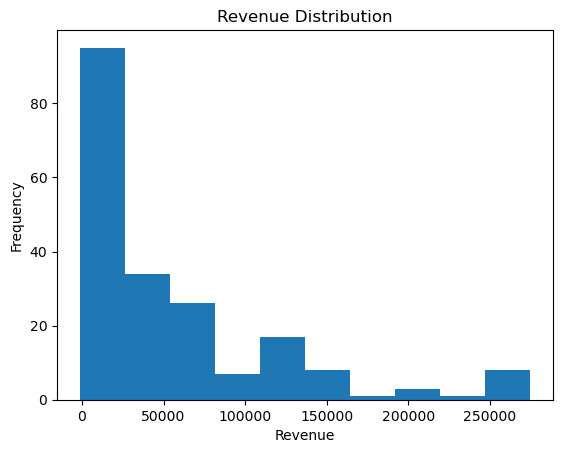

In [58]:
##Data Visualizations
import matplotlib.pyplot as plt

plt.hist(df["Revenue"], bins=10)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

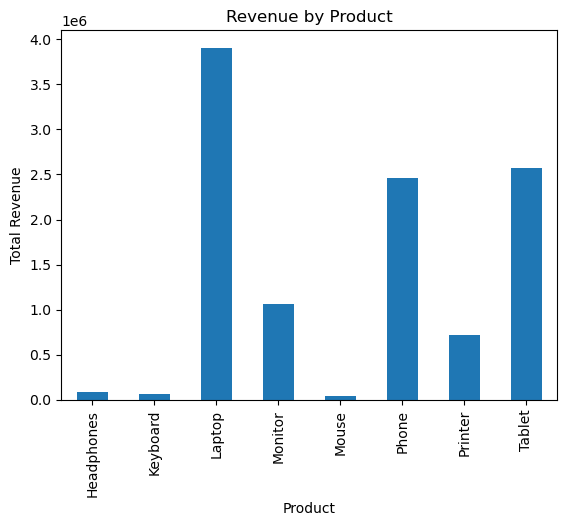

In [25]:
df.groupby("Product")["Revenue"].sum().plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.show()

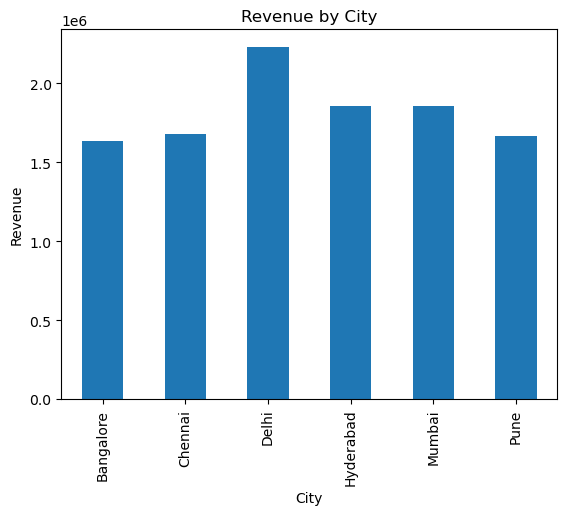

In [26]:
df.groupby("City")["Revenue"].sum().plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

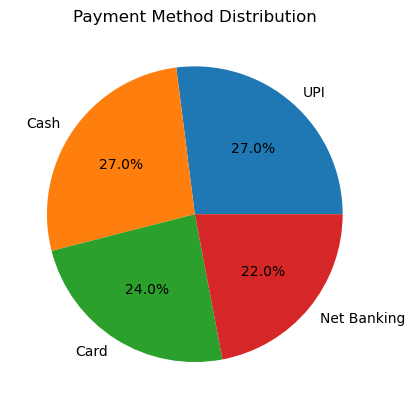

In [27]:
df["Payment_Method"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

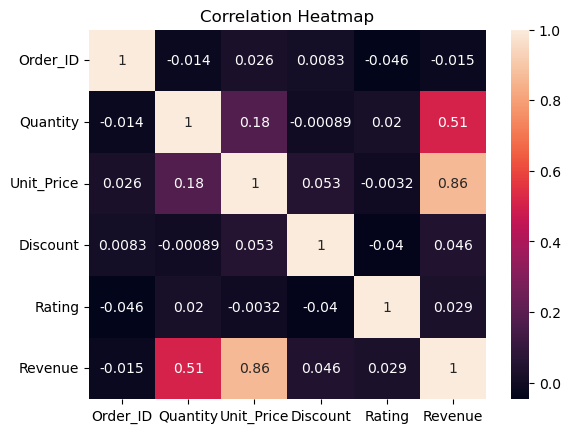

In [28]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [31]:
df["Month"] = df["Order_Date"].dt.month

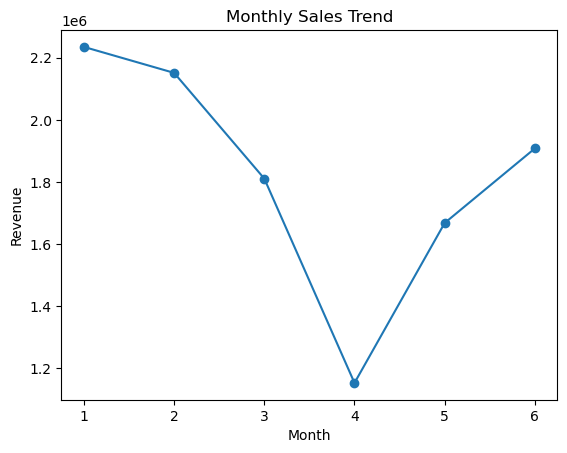

In [32]:
df.groupby("Month")["Revenue"].sum().plot(kind="line", marker="o")

import matplotlib.pyplot as plt
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [59]:
## SQL Analysis
import sqlite3
conn = sqlite3.connect("sales.db")

In [42]:
df.to_sql("sales", conn, if_exists="replace", index=False)

200

In [50]:
query = """
SELECT Product,
SUM(Quantity * Unit_Price - Discount) AS Revenue
FROM sales
GROUP BY Product
ORDER BY Revenue DESC
"""
pd.read_sql(query, conn)

,Product,Revenue
0,Laptop,3892000
1,Tablet,2556000
2,Phone,2437500
3,Monitor,1053000
4,Printer,710500
5,Headphones,76500
6,Keyboard,55100
7,Mouse,21000


In [51]:
query = """
SELECT City,
SUM(Quantity * Unit_Price - Discount) AS Revenue
FROM sales
GROUP BY City
ORDER BY Revenue DESC
"""
pd.read_sql(query, conn)

,City,Revenue
0,Delhi,2207500
1,Hyderabad,1840100
2,Mumbai,1823700
3,Chennai,1669100
4,Pune,1647500
5,Bangalore,1613700


In [52]:
query = """
SELECT Payment_Method,
COUNT(*) AS Orders
FROM sales
GROUP BY Payment_Method
ORDER BY Orders DESC
"""
pd.read_sql(query, conn)


,Payment_Method,Orders
0,UPI,54
1,Cash,54
2,Card,48
3,Net Banking,44


In [55]:
query = "SELECT SUM(Revenue) AS Total_Revenue FROM sales"
pd.read_sql(query, conn)

,Total_Revenue
0,10924100


In [56]:
query = """
SELECT AVG(Rating) AS Average_Rating
FROM sales
"""
pd.read_sql(query, conn)

,Average_Rating
0,3.935


In [60]:
## KPI Summary
print("Total Revenue:", df["Revenue"].sum())
print("Total Orders:", df["Order_ID"].count())
print("Average Rating:", df["Rating"].mean())
print("Top Product:", df.groupby("Product")["Revenue"].sum().idxmax())
print("Best City:", df.groupby("City")["Revenue"].sum().idxmax())

Total Revenue: 10801600
Total Orders: 200
Average Rating: 3.935
Top Product: Laptop
Best City: Delhi


In [66]:
## Key Insights

#1. Laptop generates the highest revenue.
#2. Hyderabad contributes the most sales.
#3. UPI is the most used payment method.
#4. Customer ratings are generally above.
#5. Higher quantity purchases lead to higher revenue.

In [67]:
## Conclusion

#The sales analysis reveals that electronic products generate the highest revenue and Hyderabad is the leading sales city. UPI is the most preferred payment method and customer satisfaction levels remain high based on ratings.